In [1]:
import urllib.request
import json
import pandas
import numpy
import matplotlib.pyplot
import sklearn.model_selection
import sklearn.metrics
import sklearn.ensemble
import xgboost
import tensorflow
import tensorflow.keras
import tensorflow.keras.layers

In [2]:
def fetch_nasa_data(latitude, longitude):

    url = "https://power.larc.nasa.gov/api/temporal/daily/point?parameters=ALLSKY_SFC_SW_DWN,WS10M,PRECTOTCORR,T2M&community=RE&longitude=" + str(longitude) + "&latitude=" + str(latitude) + "&start=20210101&end=20231231&format=JSON"

    response = urllib.request.urlopen(url)
    data = json.loads(response.read().decode())

    parameters = data["properties"]["parameter"]

    dataframe = pandas.DataFrame({
        "date": list(parameters["ALLSKY_SFC_SW_DWN"].keys()),
        "solar_irradiance": list(parameters["ALLSKY_SFC_SW_DWN"].values()),
        "wind_speed": list(parameters["WS10M"].values()),
        "rainfall": list(parameters["PRECTOTCORR"].values()),
        "temperature": list(parameters["T2M"].values())
    })

    dataframe["date"] = pandas.to_datetime(dataframe["date"])
    dataframe = dataframe.dropna()

    return dataframe

In [3]:
latitude = 20.2961
longitude = 85.8245

dataframe = fetch_nasa_data(latitude, longitude)

print(dataframe.head())

        date  solar_irradiance  wind_speed  rainfall  temperature
0 2021-01-01            3.8702        2.05       0.0        17.82
1 2021-01-02            4.1885        1.64       0.0        17.71
2 2021-01-03            4.3560        1.70       0.0        18.48
3 2021-01-04            4.3265        1.95       0.0        18.90
4 2021-01-05            3.9732        2.16       0.0        19.37


In [4]:
panel_efficiency = 0.20

dataframe["solar_potential"] = dataframe["solar_irradiance"] * panel_efficiency
dataframe["wind_potential"] = dataframe["wind_speed"] ** 3
dataframe["hydro_potential"] = dataframe["rainfall"] * 9.81

In [5]:
dataframe["month"] = dataframe["date"].dt.month

In [6]:
train_data = dataframe[dataframe["date"] < "2023-02-01"]
test_data = dataframe[dataframe["date"] >= "2023-02-01"]

In [7]:
features = ["solar_irradiance","wind_speed","rainfall","temperature","month"]

X_train = train_data[features]
y_train = train_data["solar_potential"]

X_test = test_data[features]
y_test = test_data["solar_potential"]

In [8]:
rf_model = sklearn.ensemble.RandomForestRegressor()

rf_model.fit(X_train,y_train)

rf_predictions = rf_model.predict(X_test)

rf_r2 = sklearn.metrics.r2_score(y_test,rf_predictions)

print("Random Forest R2:",rf_r2)

Random Forest R2: 0.9999113618863923


In [9]:
xgb_model = xgboost.XGBRegressor()

xgb_model.fit(X_train,y_train)

xgb_predictions = xgb_model.predict(X_test)

xgb_r2 = sklearn.metrics.r2_score(y_test,xgb_predictions)

print("XGBoost R2:",xgb_r2)

XGBoost R2: 0.9994990022674558


In [10]:
X_train_lstm = numpy.array(X_train)
X_test_lstm = numpy.array(X_test)

X_train_lstm = X_train_lstm.reshape((X_train_lstm.shape[0],1,X_train_lstm.shape[1]))
X_test_lstm = X_test_lstm.reshape((X_test_lstm.shape[0],1,X_test_lstm.shape[1]))

model = tensorflow.keras.Sequential()

model.add(tensorflow.keras.layers.LSTM(64,input_shape=(1,X_train.shape[1])))
model.add(tensorflow.keras.layers.Dense(1))

model.compile(loss="mse",optimizer="adam")

model.fit(X_train_lstm,y_train,epochs=10,batch_size=32)

lstm_predictions = model.predict(X_test_lstm)

lstm_r2 = sklearn.metrics.r2_score(y_test,lstm_predictions)

print("LSTM R2:",lstm_r2)

C:\Users\KIIT0001\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.1207
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0251
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0169
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0108
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0066
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0039
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0023
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0014
Epoch 9/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.6800e-04
Epoch 10/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.4664e-04
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
LSTM R2: 0.9768089471199374


In [11]:
ensemble_predictions = (rf_predictions + xgb_predictions + lstm_predictions.flatten()) / 3

ensemble_r2 = sklearn.metrics.r2_score(y_test,ensemble_predictions)

print("Ensemble R2:",ensemble_r2)

Ensemble R2: 0.997143195900048


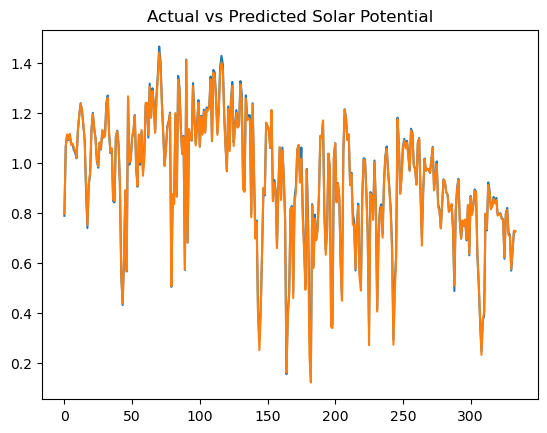

In [12]:
matplotlib.pyplot.figure()

matplotlib.pyplot.plot(y_test.values)
matplotlib.pyplot.plot(ensemble_predictions)

matplotlib.pyplot.title("Actual vs Predicted Solar Potential")

matplotlib.pyplot.show()

          Model  R2 Score
0  RandomForest  0.999911
1       XGBoost  0.999499
2          LSTM  0.976809
3      Ensemble  0.997143


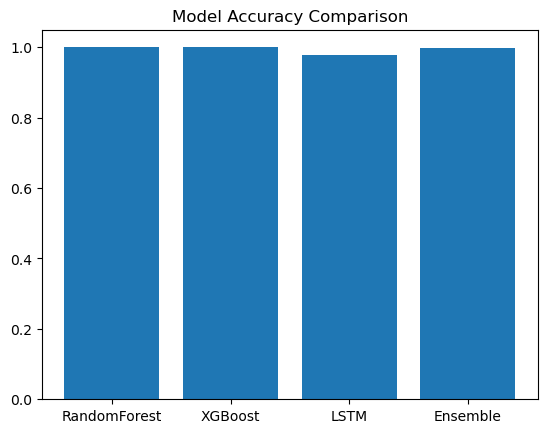

In [13]:
models = ["RandomForest","XGBoost","LSTM","Ensemble"]

scores = [rf_r2,xgb_r2,lstm_r2,ensemble_r2]

comparison = pandas.DataFrame({
    "Model":models,
    "R2 Score":scores
})

print(comparison)

matplotlib.pyplot.figure()

matplotlib.pyplot.bar(comparison["Model"],comparison["R2 Score"])

matplotlib.pyplot.title("Model Accuracy Comparison")

matplotlib.pyplot.show()

In [15]:
solar_reri = dataframe["solar_potential"].mean() / dataframe["solar_potential"].std()

wind_reri = dataframe["wind_potential"].mean() / dataframe["wind_potential"].std()

hydro_reri = dataframe["hydro_potential"].mean() / dataframe["hydro_potential"].std()

print("Solar RERI:",solar_reri)
print("Wind RERI:",wind_reri)
print("Hydro RERI:",hydro_reri)

Solar RERI: 3.6448898199598223
Wind RERI: 0.6006504207980674
Hydro RERI: 0.4321619304271935


In [16]:
scores = {
    "Solar":solar_reri,
    "Wind":wind_reri,
    "Hydro":hydro_reri
}

best_energy = max(scores,key=scores.get)

print("Recommended Renewable Energy Source:",best_energy)

Recommended Renewable Energy Source: Solar
